In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('insulin_dosage_prediction.csv')

In [3]:
df

,patient_id,gender,age,family_history,glucose_level,physical_activity,food_intake,previous_medications,BMI,HbA1c,weight,insulin_sensitivity,sleep_hours,creatinine,Insulin
0,1,male,68,yes,103.49,9.28,high,none,33.87,7.42,54.77,1.49,6.07,0.63,steady
1,2,female,57,yes,113.35,6.67,high,insulin,19.10,11.66,114.93,1.35,8.60,1.08,up
2,3,male,24,yes,127.40,4.14,medium,oral,22.48,5.72,59.07,0.96,5.19,1.36,up
3,4,male,49,yes,138.79,6.80,medium,oral,31.67,11.91,50.81,0.61,4.79,1.23,up
4,5,male,65,no,128.42,4.01,low,insulin,28.50,5.72,65.95,1.16,7.68,0.62,steady
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,female,33,no,193.35,6.40,high,none,29.20,4.74,61.66,1.33,6.18,0.58,no
9996,9997,male,77,yes,140.01,2.28,low,none,34.41,4.93,66.62,0.84,6.74,0.74,up
9997,9998,female,71,yes,190.90,8.53,medium,oral,26.82,9.64,76.26,1.47,9.71,0.67,steady
9998,9999,female,33,yes,164.27,7.50,high,none,29.82,9.34,94.50,1.04,8.49,0.96,no


In [4]:
df.shape

(10000, 15)

In [5]:
df.head()

,patient_id,gender,age,family_history,glucose_level,physical_activity,food_intake,previous_medications,BMI,HbA1c,weight,insulin_sensitivity,sleep_hours,creatinine,Insulin
0,1,male,68,yes,103.49,9.28,high,none,33.87,7.42,54.77,1.49,6.07,0.63,steady
1,2,female,57,yes,113.35,6.67,high,insulin,19.10,11.66,114.93,1.35,8.60,1.08,up
2,3,male,24,yes,127.40,4.14,medium,oral,22.48,5.72,59.07,0.96,5.19,1.36,up
3,4,male,49,yes,138.79,6.80,medium,oral,31.67,11.91,50.81,0.61,4.79,1.23,up
4,5,male,65,no,128.42,4.01,low,insulin,28.50,5.72,65.95,1.16,7.68,0.62,steady


In [6]:
df.tail()

,patient_id,gender,age,family_history,glucose_level,physical_activity,food_intake,previous_medications,BMI,HbA1c,weight,insulin_sensitivity,sleep_hours,creatinine,Insulin
9995,9996,female,33,no,193.35,6.40,high,none,29.20,4.74,61.66,1.33,6.18,0.58,no
9996,9997,male,77,yes,140.01,2.28,low,none,34.41,4.93,66.62,0.84,6.74,0.74,up
9997,9998,female,71,yes,190.90,8.53,medium,oral,26.82,9.64,76.26,1.47,9.71,0.67,steady
9998,9999,female,33,yes,164.27,7.50,high,none,29.82,9.34,94.50,1.04,8.49,0.96,no
9999,10000,male,52,yes,104.39,5.17,high,oral,24.57,10.43,103.03,0.53,8.01,1.21,up


In [7]:
df.isnull().sum()

patient_id              0
gender                  0
age                     0
family_history          0
glucose_level           0
physical_activity       0
food_intake             0
previous_medications    0
BMI                     0
HbA1c                   0
weight                  0
insulin_sensitivity     0
sleep_hours             0
creatinine              0
Insulin                 0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

patient_id                int64
gender                   object
age                       int64
family_history           object
glucose_level           float64
physical_activity       float64
food_intake              object
previous_medications     object
BMI                     float64
HbA1c                   float64
weight                  float64
insulin_sensitivity     float64
sleep_hours             float64
creatinine              float64
Insulin                  object
dtype: object

In [10]:
df.select_dtypes(include='object').columns

Index(['gender', 'family_history', 'food_intake', 'previous_medications',
       'Insulin'],
      dtype='object')

In [11]:
import seaborn as sns

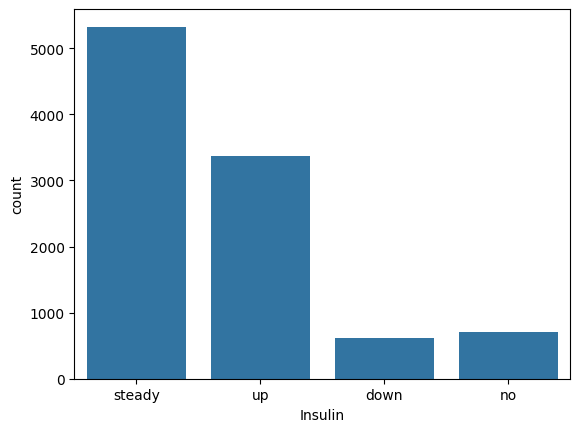

In [12]:
sns.countplot(data=df,x='Insulin')
plt.show()

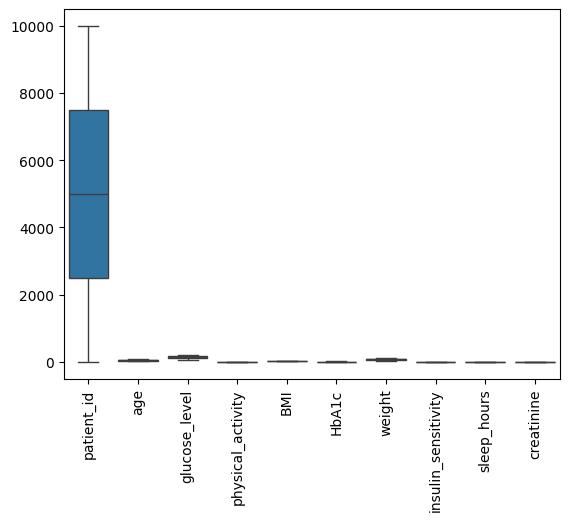

In [13]:
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

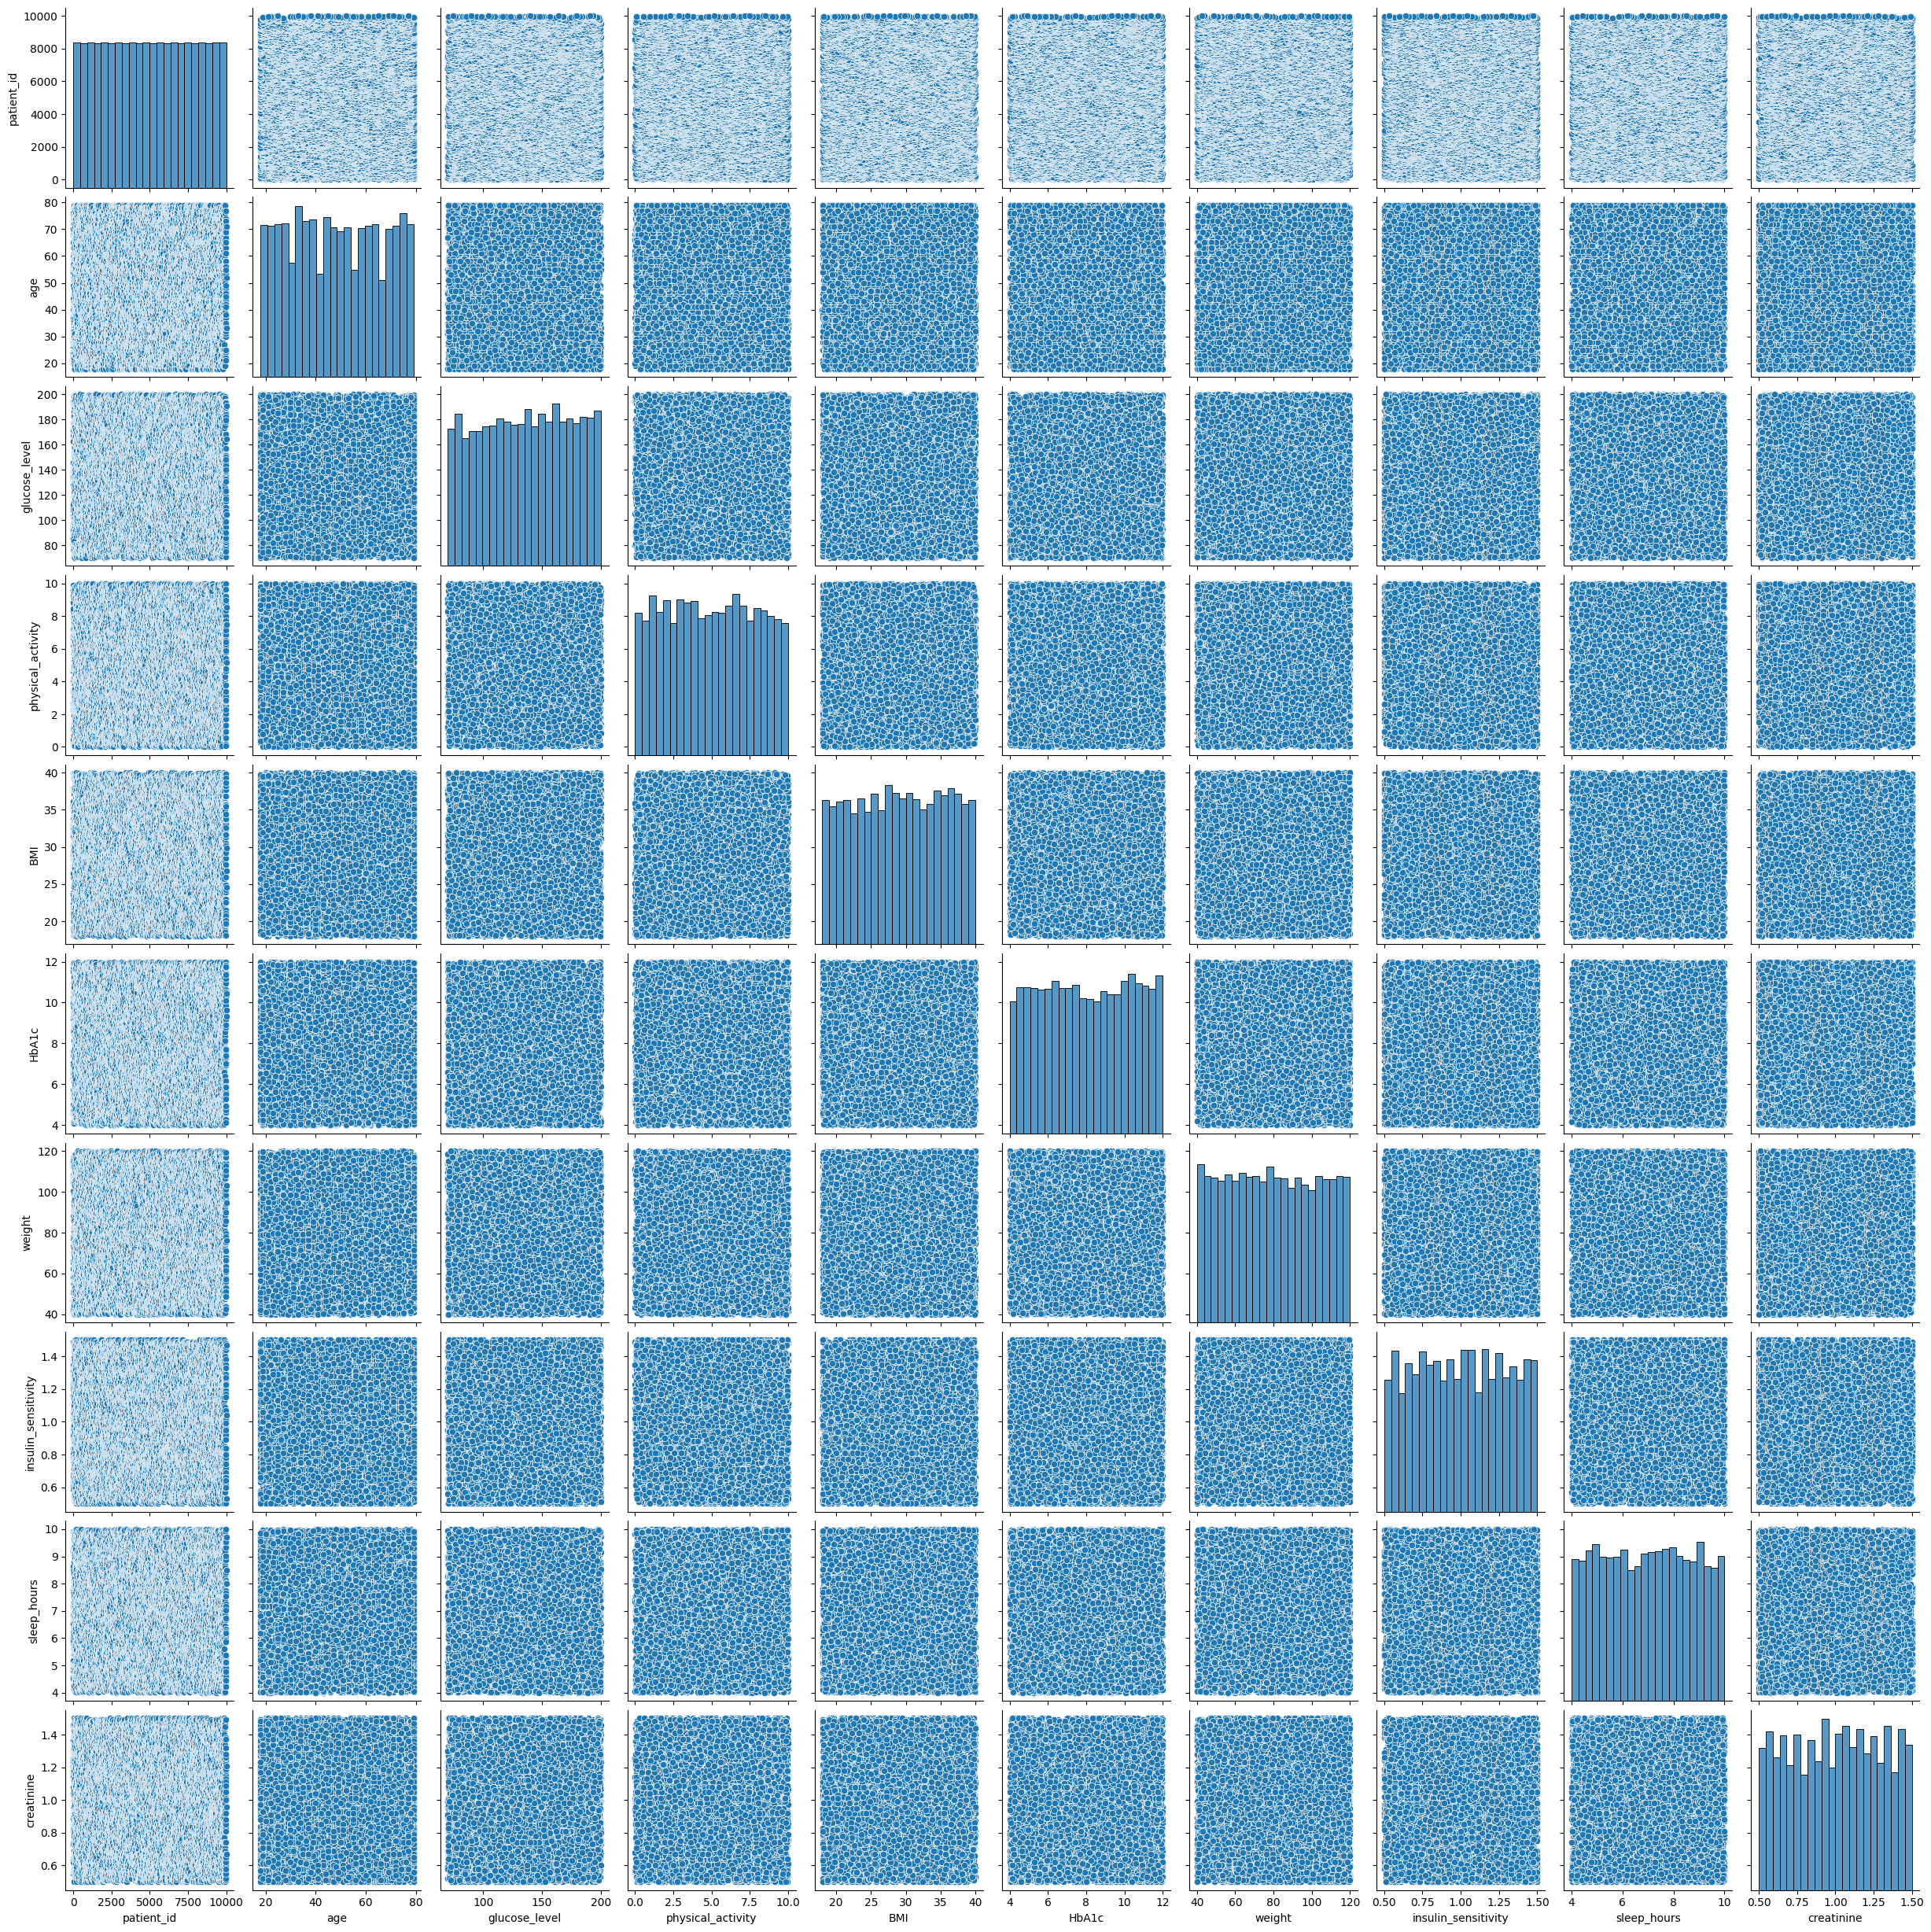

In [14]:
sns.pairplot(df)

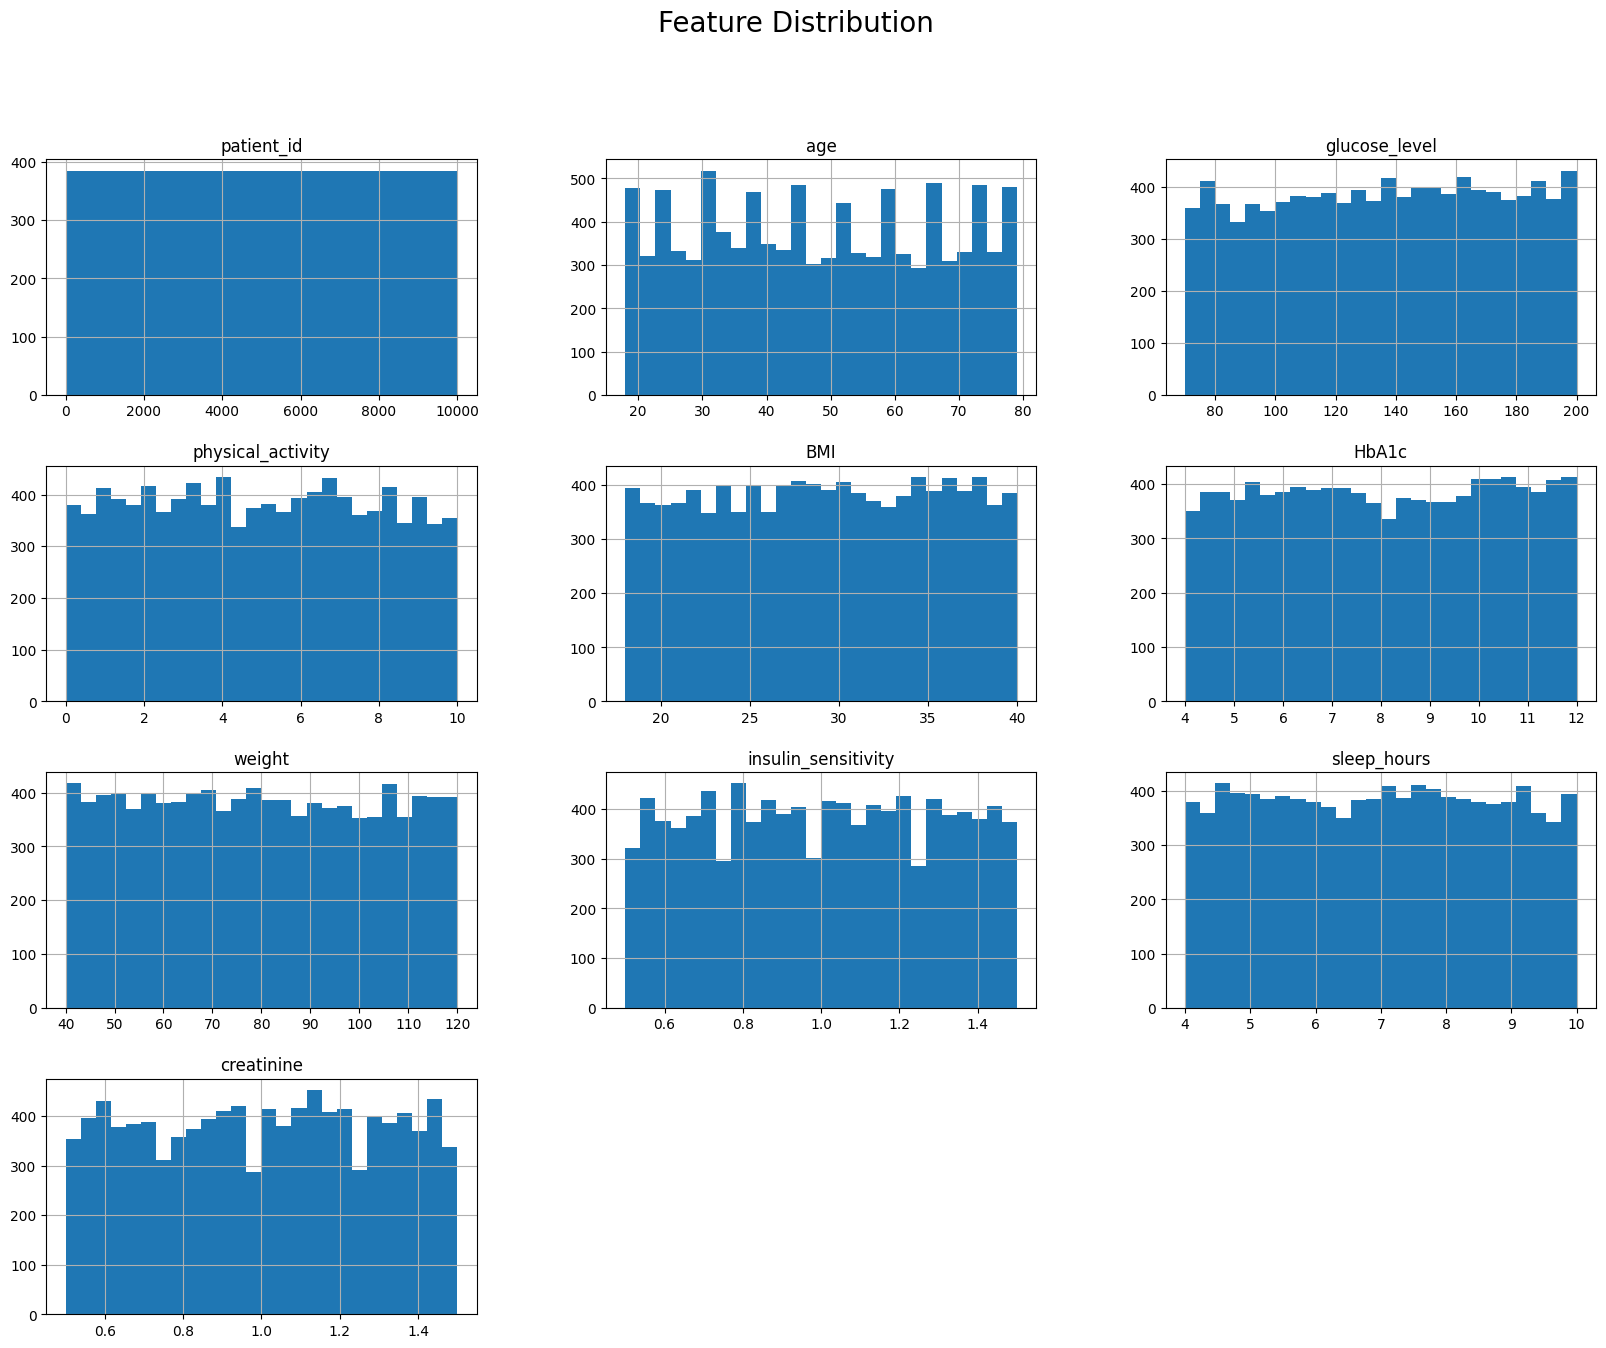

In [15]:
# HISTPLOT
df.hist(figsize=(20, 15), bins=26)
plt.suptitle("Feature Distribution", fontsize=20)
plt.show()

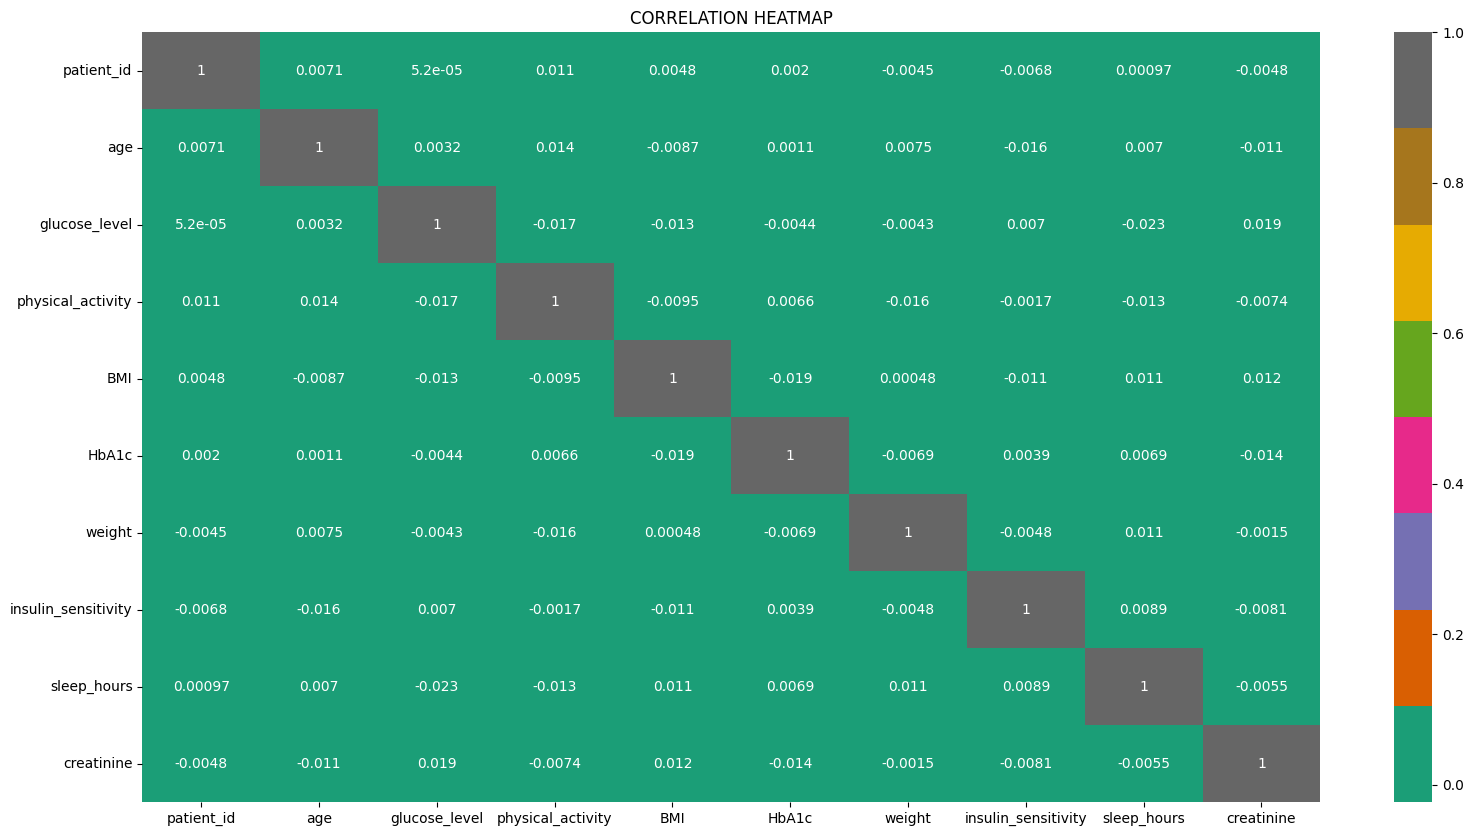

In [16]:
plt.figure(figsize=(19,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Dark2')
plt.title("CORRELATION HEATMAP")
plt.show()


# PREPROCESSING

In [17]:
df

,patient_id,gender,age,family_history,glucose_level,physical_activity,food_intake,previous_medications,BMI,HbA1c,weight,insulin_sensitivity,sleep_hours,creatinine,Insulin
0,1,male,68,yes,103.49,9.28,high,none,33.87,7.42,54.77,1.49,6.07,0.63,steady
1,2,female,57,yes,113.35,6.67,high,insulin,19.10,11.66,114.93,1.35,8.60,1.08,up
2,3,male,24,yes,127.40,4.14,medium,oral,22.48,5.72,59.07,0.96,5.19,1.36,up
3,4,male,49,yes,138.79,6.80,medium,oral,31.67,11.91,50.81,0.61,4.79,1.23,up
4,5,male,65,no,128.42,4.01,low,insulin,28.50,5.72,65.95,1.16,7.68,0.62,steady
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,female,33,no,193.35,6.40,high,none,29.20,4.74,61.66,1.33,6.18,0.58,no
9996,9997,male,77,yes,140.01,2.28,low,none,34.41,4.93,66.62,0.84,6.74,0.74,up
9997,9998,female,71,yes,190.90,8.53,medium,oral,26.82,9.64,76.26,1.47,9.71,0.67,steady
9998,9999,female,33,yes,164.27,7.50,high,none,29.82,9.34,94.50,1.04,8.49,0.96,no


In [18]:
df.columns

Index(['patient_id', 'gender', 'age', 'family_history', 'glucose_level',
       'physical_activity', 'food_intake', 'previous_medications', 'BMI',
       'HbA1c', 'weight', 'insulin_sensitivity', 'sleep_hours', 'creatinine',
       'Insulin'],
      dtype='object')

In [19]:
df = df.drop([
    'patient_id',
], axis=1, errors='ignore')

In [20]:
df.dtypes

gender                   object
age                       int64
family_history           object
glucose_level           float64
physical_activity       float64
food_intake              object
previous_medications     object
BMI                     float64
HbA1c                   float64
weight                  float64
insulin_sensitivity     float64
sleep_hours             float64
creatinine              float64
Insulin                  object
dtype: object

In [21]:
sklearn import LabelEncoder()

In [22]:
le0=LabelEncoder()

In [23]:
df['gender'] = le0.fit_transform(df['gender'])

In [24]:
le1=LabelEncoder()

In [25]:
df['family_history'] = le1.fit_transform(df['family_history'])

In [26]:
le2=LabelEncoder()

In [27]:
df['food_intake'] = le2.fit_transform(df['food_intake'])

In [28]:
le3=LabelEncoder()

In [29]:
df['previous_medications'] = le3.fit_transform(df['previous_medications'])

In [30]:
le4=LabelEncoder()

In [31]:
df['Insulin'] = le4.fit_transform(df['Insulin'])

In [32]:
df['Insulin'].value_counts()

Insulin
2    5326
3    3363
1     701
0     610
Name: count, dtype: int64

In [33]:
df

,gender,age,family_history,glucose_level,physical_activity,food_intake,previous_medications,BMI,HbA1c,weight,insulin_sensitivity,sleep_hours,creatinine,Insulin
0,1,68,1,103.49,9.28,0,2,33.87,7.42,54.77,1.49,6.07,0.63,2
1,0,57,1,113.35,6.67,0,1,19.10,11.66,114.93,1.35,8.60,1.08,3
2,1,24,1,127.40,4.14,2,3,22.48,5.72,59.07,0.96,5.19,1.36,3
3,1,49,1,138.79,6.80,2,3,31.67,11.91,50.81,0.61,4.79,1.23,3
4,1,65,0,128.42,4.01,1,1,28.50,5.72,65.95,1.16,7.68,0.62,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,33,0,193.35,6.40,0,2,29.20,4.74,61.66,1.33,6.18,0.58,1
9996,1,77,1,140.01,2.28,1,2,34.41,4.93,66.62,0.84,6.74,0.74,3
9997,0,71,1,190.90,8.53,2,3,26.82,9.64,76.26,1.47,9.71,0.67,2
9998,0,33,1,164.27,7.50,0,2,29.82,9.34,94.50,1.04,8.49,0.96,1


In [34]:
df['Insulin'].value_counts()

Insulin
2    5326
3    3363
1     701
0     610
Name: count, dtype: int64

In [35]:
y = df['Insulin']
x = df.drop('Insulin', axis=1)

In [36]:
y

0       2
1       3
2       3
3       3
4       2
       ..
9995    1
9996    3
9997    2
9998    1
9999    3
Name: Insulin, Length: 10000, dtype: int64

In [37]:
x

,gender,age,family_history,glucose_level,physical_activity,food_intake,previous_medications,BMI,HbA1c,weight,insulin_sensitivity,sleep_hours,creatinine
0,1,68,1,103.49,9.28,0,2,33.87,7.42,54.77,1.49,6.07,0.63
1,0,57,1,113.35,6.67,0,1,19.10,11.66,114.93,1.35,8.60,1.08
2,1,24,1,127.40,4.14,2,3,22.48,5.72,59.07,0.96,5.19,1.36
3,1,49,1,138.79,6.80,2,3,31.67,11.91,50.81,0.61,4.79,1.23
4,1,65,0,128.42,4.01,1,1,28.50,5.72,65.95,1.16,7.68,0.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,33,0,193.35,6.40,0,2,29.20,4.74,61.66,1.33,6.18,0.58
9996,1,77,1,140.01,2.28,1,2,34.41,4.93,66.62,0.84,6.74,0.74
9997,0,71,1,190.90,8.53,2,3,26.82,9.64,76.26,1.47,9.71,0.67
9998,0,33,1,164.27,7.50,0,2,29.82,9.34,94.50,1.04,8.49,0.96


In [38]:
from sklearn.preprocessing import StandardScaler

In [39]:
df

,gender,age,family_history,glucose_level,physical_activity,food_intake,previous_medications,BMI,HbA1c,weight,insulin_sensitivity,sleep_hours,creatinine,Insulin
0,1,68,1,103.49,9.28,0,2,33.87,7.42,54.77,1.49,6.07,0.63,2
1,0,57,1,113.35,6.67,0,1,19.10,11.66,114.93,1.35,8.60,1.08,3
2,1,24,1,127.40,4.14,2,3,22.48,5.72,59.07,0.96,5.19,1.36,3
3,1,49,1,138.79,6.80,2,3,31.67,11.91,50.81,0.61,4.79,1.23,3
4,1,65,0,128.42,4.01,1,1,28.50,5.72,65.95,1.16,7.68,0.62,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,33,0,193.35,6.40,0,2,29.20,4.74,61.66,1.33,6.18,0.58,1
9996,1,77,1,140.01,2.28,1,2,34.41,4.93,66.62,0.84,6.74,0.74,3
9997,0,71,1,190.90,8.53,2,3,26.82,9.64,76.26,1.47,9.71,0.67,2
9998,0,33,1,164.27,7.50,0,2,29.82,9.34,94.50,1.04,8.49,0.96,1


In [40]:
Scaler=StandardScaler()
x=Scaler.fit_transform(x)

In [41]:
from sklearn.model_selection import train_test_split,GridSearchCV

In [42]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=60, stratify=y)

In [45]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE:", Counter(y_train))

sm = SMOTE(random_state=42)
x_train, y_train = sm.fit_resample(x_train, y_train)

print("After SMOTE:", Counter(y_train))

Before SMOTE: Counter({2: 3994, 3: 2522, 1: 526, 0: 458})
After SMOTE: Counter({1: 3994, 3: 3994, 2: 3994, 0: 3994})


# LOGISTIC REGRESSION

In [46]:
from sklearn.linear_model import LogisticRegression

In [148]:
lr=LogisticRegression(max_iter=3000,random_state=42)

lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [149]:
lr_train = lr.score(x_train, y_train)
lr_test = lr.score(x_test, y_test)

In [150]:
lr_train

0.5981333333333333

In [151]:
lr_test

0.59

In [51]:
y_pred=lr.predict(x_test)
y_pred

array([2, 1, 1, ..., 2, 2, 3], shape=(2500,))

In [52]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay

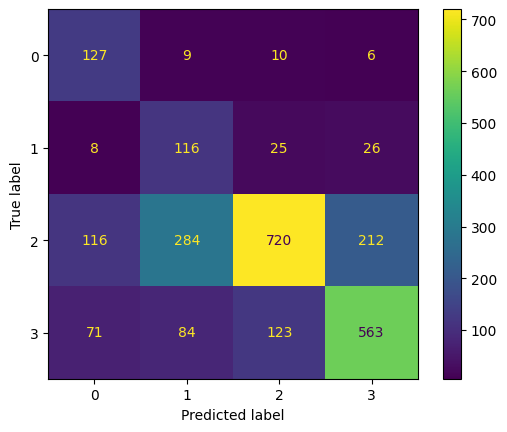

In [53]:
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [54]:
print('CR:',classification_report(y_test,y_pred))

CR:               precision    recall  f1-score   support

           0       0.39      0.84      0.54       152
           1       0.24      0.66      0.35       175
           2       0.82      0.54      0.65      1332
           3       0.70      0.67      0.68       841

    accuracy                           0.61      2500
   macro avg       0.54      0.68      0.55      2500
weighted avg       0.71      0.61      0.63      2500



# DECISIONTREEE CLASSIFIER

In [55]:
from sklearn.tree import DecisionTreeClassifier

In [56]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [57]:
dt= DecisionTreeClassifier(random_state=42,max_depth=5)
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [58]:
dt_train = dt.score(x_train, y_train)
dt_test = dt.score(x_test, y_test)

In [59]:
dt_train

0.8781333333333333

In [60]:
dt_test

0.8676


# RANDOMFOREST CLASSIFIER

In [61]:
from sklearn.ensemble import RandomForestClassifier

In [62]:
rf= RandomForestClassifier(n_estimators=200,max_depth=6,random_state=42)
rf.fit(x_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [63]:
rf_train = rf.score(x_train, y_train)
rf_test = rf.score(x_test, y_test)

In [64]:
rf_train

0.9089333333333334

In [65]:
rf_test

0.8992

In [66]:
y_pred=rf.predict(x_test)
y_pred

array([2, 2, 3, ..., 3, 2, 2], shape=(2500,))

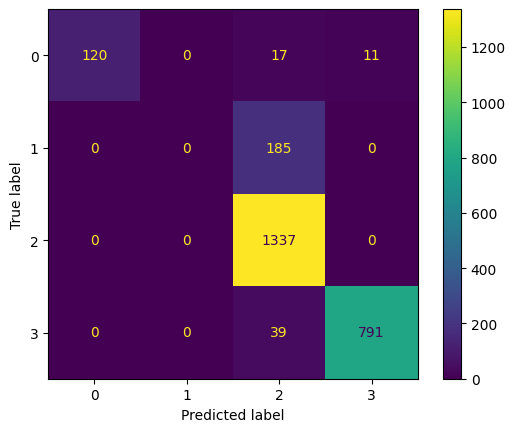

In [67]:
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [68]:
print('CR:',classification_report(y_test,y_pred))

CR:               precision    recall  f1-score   support

           0       1.00      0.81      0.90       148
           1       0.00      0.00      0.00       185
           2       0.85      1.00      0.92      1337
           3       0.99      0.95      0.97       830

    accuracy                           0.90      2500
   macro avg       0.71      0.69      0.70      2500
weighted avg       0.84      0.90      0.87      2500



c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

# KNN  KNeighborsClassifier

In [69]:
from sklearn.neighbors import KNeighborsClassifier

In [70]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=60)

In [71]:
knn= KNeighborsClassifier(n_neighbors=75)
knn.fit(x_train,y_train)

,n_neighbors,75
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [72]:
knn_train = knn.score(x_train, y_train)
knn_test = knn.score(x_test, y_test)

In [73]:
knn_train

0.7498666666666667

In [74]:
knn_test

0.7468

In [75]:
y_pred=knn.predict(x_test)
y_pred

array([2, 3, 2, ..., 2, 2, 2], shape=(2500,))

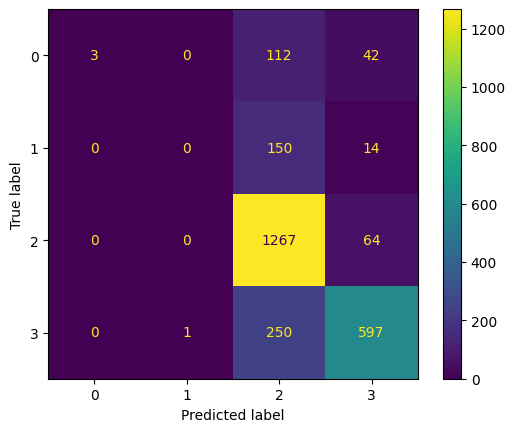

In [76]:
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [77]:
print('CR:',classification_report(y_test,y_pred))

CR:               precision    recall  f1-score   support

           0       1.00      0.02      0.04       157
           1       0.00      0.00      0.00       164
           2       0.71      0.95      0.81      1331
           3       0.83      0.70      0.76       848

    accuracy                           0.75      2500
   macro avg       0.64      0.42      0.40      2500
weighted avg       0.72      0.75      0.69      2500



# SUPPORT VECTOR MECHANISM (SVM)

In [78]:
from sklearn.svm import SVC

In [79]:
svm=SVC(kernel='linear')

In [80]:
svm.fit(x_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [81]:
svm_test=svm.score(x_test,y_test)
svm_train=svm.score(x_train,y_train)

In [82]:
svm_train

0.7584

In [83]:
svm_test

0.7628

# Polynomial Kernel

In [84]:

svm1 = SVC(kernel='poly',degree=2,C=0.5)
svm1.fit(x_train, y_train)


,C,0.5
,kernel,'poly'
,degree,2
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [85]:
svm1.score(x_train,y_train)

0.6337333333333334

In [86]:
svm1.score(x_test,y_test)

0.6164

# SIGMOID

In [87]:
svm_sig=SVC(kernel='sigmoid',C=0.1)
svm_sig.fit(x_train,y_train)

,C,0.1
,kernel,'sigmoid'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [88]:
svm_sig.score(x_train,y_train)

0.7378666666666667

In [89]:
svm_sig.score(x_test,y_test)

0.742

# NAIVE BAYES

In [90]:
from sklearn.naive_bayes import GaussianNB

In [91]:
nb=GaussianNB()

In [92]:
nb.fit(x_train,y_train)

,priors,None
,var_smoothing,1e-09


In [93]:
nb_train = nb.score(x_train, y_train)
nb_test = nb.score(x_test, y_test)

In [94]:
nb_train

0.6841333333333334

In [95]:
nb_test

0.68

In [96]:
y_pred=nb.predict(x_test)
y_pred

array([0, 3, 2, ..., 2, 3, 2], shape=(2500,))

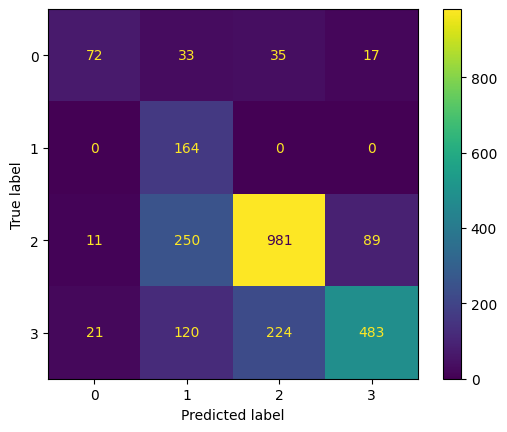

In [97]:
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

# ENSEMBLE MODEL

# ADABOOST

In [98]:
from sklearn.ensemble import AdaBoostClassifier

In [99]:
adaBoost=AdaBoostClassifier(n_estimators=50,learning_rate=0.3,random_state=1)

In [100]:
adaBoost.fit(x_train,y_train)

,estimator,None
,n_estimators,50
,learning_rate,0.3
,algorithm,'deprecated'
,random_state,1


In [101]:
ada_train = adaBoost.score(x_train, y_train)
ada_test = adaBoost.score(x_test, y_test)

In [102]:
ada_train

0.77

In [103]:
ada_test

0.7832

In [104]:
y_pred=adaBoost.predict(x_test)
y_pred

array([0, 3, 2, ..., 2, 2, 3], shape=(2500,))

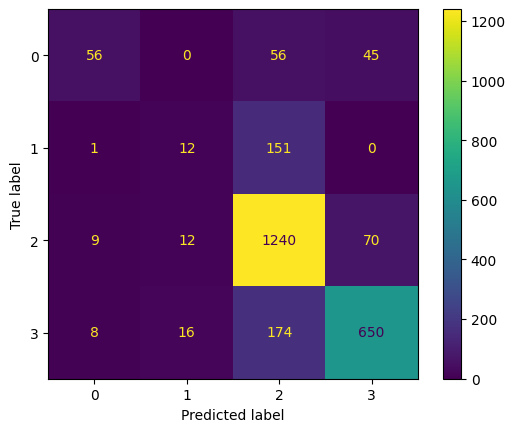

In [105]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

# Gradient Boosting

In [106]:
from sklearn.ensemble import GradientBoostingClassifier

In [107]:
gcb=GradientBoostingClassifier(n_estimators=50,learning_rate=0.05,random_state=100)
gcb.fit(x_train,y_train)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [108]:
gcb_train = gcb.score(x_train, y_train)
gcb_test = gcb.score(x_test, y_test)

In [109]:
gcb_train

0.9664

In [110]:
gcb_test

0.9584

In [111]:
y_pred=gcb.predict(x_test)
y_pred

array([0, 3, 2, ..., 2, 2, 2], shape=(2500,))

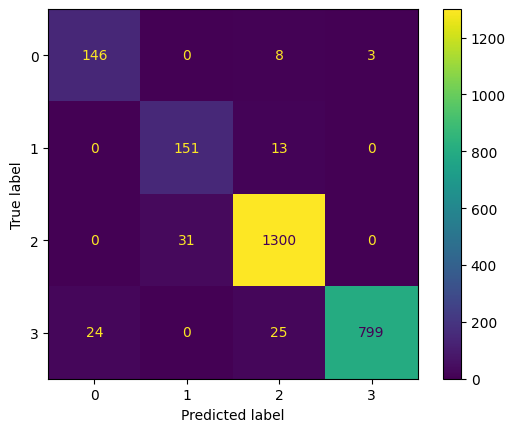

In [112]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

# XGBoost (Extreme Gradient Boosting)

In [113]:
from xgboost import XGBClassifier

In [114]:
xgb=XGBClassifier(max_depth=3,n_estimators=50,random_state=42,learning_rate=0.05)
xgb.fit(x_train,y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [115]:

xgb_train = xgb.score(x_train, y_train)
xgb_test = xgb.score(x_test, y_test)

In [116]:
xgb_train

0.9192

In [117]:
xgb_test

0.92

In [118]:
y_pred=xgb.predict(x_test)
y_pred

array([0, 3, 2, ..., 2, 2, 2], shape=(2500,))

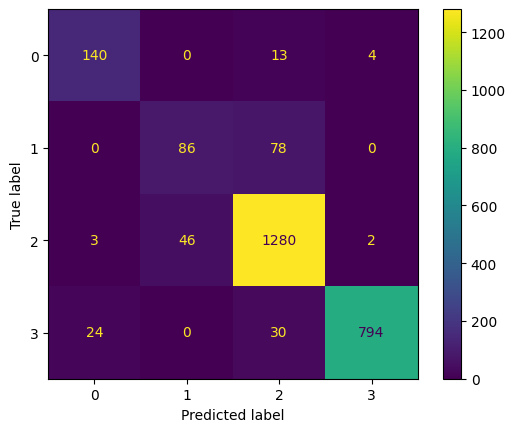

In [119]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

In [152]:
tb = pd.DataFrame()
tb['model'] = ['lr','dt','rf','knn','svm','nb','adaBoost','gcb','xgb']
tb['test_accuracy'] = [lr_test, dt_test, rf_test, knn_test, svm_test, nb_test, ada_test, gcb_test, xgb_test]
tb['train_accuracy'] = [lr_train, dt_train, rf_train, knn_train, svm_train, nb_train, ada_train, gcb_train, xgb_train]
tb

,model,test_accuracy,train_accuracy
0,lr,0.5900,0.598133
1,dt,0.8676,0.878133
2,rf,0.8992,0.908933
3,knn,0.7468,0.749867
4,svm,0.7628,0.758400
5,nb,0.6800,0.684133
6,adaBoost,0.7832,0.770000
7,gcb,0.9584,0.966400
8,xgb,0.9200,0.919200


# Cross Validation

In [121]:
from sklearn.model_selection import cross_val_score

In [122]:
score1=cross_val_score(GradientBoostingClassifier(n_estimators=20),x,y,cv=10)
np.average(score1)

np.float64(0.9449)

In [123]:
score2=cross_val_score(XGBClassifier(n_estimators=2),x,y,cv=2)
np.average(score2)

np.float64(0.9633)

In [124]:
score3=cross_val_score(RandomForestClassifier(n_estimators=5),x,y,cv=5)
np.average(score3)

np.float64(0.9429000000000001)

# HYPERPARAMETER TUNNING

In [125]:
# LOGITIC REGRESSION

ir_params={'C':[0.1,1,10]}
ir_grid=GridSearchCV(LogisticRegression(),ir_params,cv=5)
ir_grid.fit(x_train,y_train) 

,estimator,LogisticRegression()
,param_grid,"{'C': [0.1, 1, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [126]:
# DECISION TREE
dt_params={'max_depth':[2,4,6,None],'criterion':['gini','entropy']}
dt_grid=GridSearchCV(DecisionTreeClassifier(random_state=42),dt_params,cv=5)
dt_grid.fit(x_train,y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [127]:
# RANDOM FOREST

rf_params={'n_estimators':[10,50,100],'max_depth':[2,4,6,None]}
rf_grid=GridSearchCV(RandomForestClassifier(random_state=42),rf_params,cv=5)
rf_grid.fit(x_train,y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [2, 4, ...], 'n_estimators': [10, 50, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [128]:
# KNN
knn_param = {
    'n_neighbors':range(1, 31),  # Number of neighbors
    'weights':['uniform','distance'],  # Voting strategy
    'metric':['euclidean','manhattan','minkowski']  # Distance metric
}
knn_grid= GridSearchCV(knn,knn_param,cv=5,scoring='accuracy', n_jobs=-1)
knn_grid.fit(x_train,y_train)

,estimator,KNeighborsCla..._neighbors=75)
,param_grid,"{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': range(1, 31), 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,10


In [129]:
# SVM
svm_params={'C':[0.1,1,10],'kernel':['linear','rbf'],'gamma':['scale','auto']}
svm_grid=GridSearchCV(SVC(),svm_params,cv=5)
svm_grid.fit(x_train,y_train)

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [130]:
#xgb
xg_param={
     'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    }
xg_grid = GridSearchCV(XGBClassifier(),xg_param,cv=5,scoring='accuracy',n_jobs=-1)
xg_grid.fit(x_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [131]:
gb_param = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5]}
gb_grid = GridSearchCV(GradientBoostingClassifier(),gb_param,cv=5,scoring='accuracy',n_jobs=-1)
gb_grid.fit(x_train, y_train)

,estimator,GradientBoostingClassifier()
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [132]:
from sklearn.metrics import accuracy_score

In [133]:
models = {'Logistic Regression': ir_grid,
          'Decision Tree': dt_grid,
          'Random Forest': rf_grid,
          'KNN':knn_grid,
          'SVM': svm_grid,
          'xgb':xg_grid,
          'GB':gb_grid }
for name, grid in models.items():
    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}:")
    print(f"  Best Params: {grid.best_params_}")
    print(f"  Accuracy: {acc:.4f}\n")

Logistic Regression:
  Best Params: {'C': 1}
  Accuracy: 0.7460

Decision Tree:
  Best Params: {'criterion': 'entropy', 'max_depth': None}
  Accuracy: 0.9856

Random Forest:
  Best Params: {'max_depth': None, 'n_estimators': 100}
  Accuracy: 0.9740



KNN:
  Best Params: {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'distance'}
  Accuracy: 0.8164

SVM:
  Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  Accuracy: 0.8864

xgb:
  Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
  Accuracy: 0.9952

GB:
  Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}
  Accuracy: 0.9980



In [134]:
# Access the best model
best_gcb_model = gb_grid.best_estimator_
y_pred = best_gcb_model.predict(x_test)

In [135]:
print(best_gcb_model)

GradientBoostingClassifier(n_estimators=200)


In [136]:
model_input=['gender','age','family_history','glucose_level','food_intake','previous_medications','BMI','sleep_hours']

In [137]:
X=df[model_input]

In [138]:
from sklearn.preprocessing import StandardScaler
Scaler=StandardScaler()
X_scaled=Scaler.fit_transform(X)

In [139]:
best_model.fit(X_scaled,y)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


# Joblib

In [140]:
import joblib
joblib.dump(best_model,"insulin.pkl")

['insulin.pkl']

In [141]:
joblib.dump(sc,"scaler.pkl")

['scaler.pkl']

In [142]:
joblib.dump(le0,"le0.pkl")

['le0.pkl']

In [143]:
joblib.dump(le1,"le1.pkl")

['le1.pkl']

In [144]:
joblib.dump(le2,"le2.pkl")

['le2.pkl']

In [145]:
joblib.dump(le3,"le3.pkl")

['le3.pkl']

In [146]:
joblib.dump(le4,"target.pkl")

['target.pkl']

In [147]:
joblib.dump(Scaler,"transform.pkl")

['transform.pkl']